<a href="https://colab.research.google.com/github/yusuf-codes10/deep-learining-project/blob/main/transfer_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data initialization

In [ ]:
# STEP 1 — Set Kaggle credentials (run this first)
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

Enter Kaggle API key: ··········
Enter Kaggle username: youcefcopy
Enter Kaggle API key: ··········


In [ ]:
# STEP 2 — Install Kaggle (run once per session)
!pip install -q kaggle

In [ ]:
# STEP 3 — Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:04<00:00, 19.7MB/s]



In [ ]:
# STEP 4 — Unzip dataset
!unzip -q chest-xray-pneumonia.zip

# Data Normaliation and Augmentaion

## 1- Laoding the images

In [ ]:
# ── Load all training images manually at 224x224 ──────────────────────────────
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator

def load_images_from_folder(folder, label, target_size=(128, 128)):
    images, labels = [], []
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = load_img(fpath, target_size=target_size)
            images.append(img_to_array(img) / 255.0)
            labels.append(label)
        except:
            pass
    return images, labels

normal_imgs, normal_labels       = load_images_from_folder("chest_xray/train/NORMAL",    0)
pneumonia_imgs, pneumonia_labels = load_images_from_folder("chest_xray/train/PNEUMONIA", 1)

print(f"NORMAL:    {len(normal_imgs)}")
print(f"PNEUMONIA: {len(pneumonia_imgs)}")

NORMAL:    1341
PNEUMONIA: 3875


## 2- Data Augmentaion

In [ ]:
# ── Augment NORMAL only until it matches PNEUMONIA count ────────────────────
aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

normal_imgs_aug    = list(normal_imgs)
normal_labels_aug  = list(normal_labels)
target_count       = len(pneumonia_imgs)
normal_array       = np.array(normal_imgs)

while len(normal_imgs_aug) < target_count:
    idx       = np.random.randint(0, len(normal_imgs))
    src       = normal_array[idx].reshape(1, 128, 128, 3)
    augmented = next(aug.flow(src, batch_size=1))[0]
    normal_imgs_aug.append(augmented)
    normal_labels_aug.append(0)

print(f"NORMAL after oversampling: {len(normal_imgs_aug)}")
print(f"PNEUMONIA:                 {len(pneumonia_imgs)}")

NORMAL after oversampling: 3875
PNEUMONIA:                 3875


## 3- Shuffling

In [ ]:
# ── Combine + shuffle ────────────────────────────────────────────────────────
X = np.array(normal_imgs_aug + pneumonia_imgs)
y = np.array(normal_labels_aug + pneumonia_labels)

idx  = np.random.permutation(len(X))
X, y = X[idx], y[idx]

print(f"Final dataset: {X.shape}")
print(f"NORMAL={sum(y==0)}, PNEUMONIA={sum(y==1)}")

Final dataset: (7750, 128, 128, 3)
NORMAL=3875, PNEUMONIA=3875


## 4- Splitting

In [ ]:
# ── Train/val split ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")

Train: (6200, 128, 128, 3) | Val: (1550, 128, 128, 3)


# Transfer Model

## 1- 1- Base Model (Pre-trained on ImageNet)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16

# ── Load VGG16 without the top classification head ───────────────────────────
# include_top=False → removes the final Dense layers (we'll add our own)
# input_shape must match what we loaded: 64x64x3
# weights='imagenet' → uses features learned from 1.2M images
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# ── Freeze all base layers first ─────────────────────────────────────────────
# We don't want to destroy the pre-trained ImageNet features during early training
base_model.trainable = False

print(f"Base model layers: {len(base_model.layers)}")
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Base model layers: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## 2-  Model Architecture (Custom Head on top of VGG16)

In [ ]:
from tensorflow.keras import regularizers

l2 = regularizers.l2(1e-5)

# ── Build the full model ──────────────────────────────────────────────────────
# Same structure philosophy as cnn_v3: Flatten → Dense(128) + L2 → Dropout → Sigmoid
inputs = keras.Input(shape=(128, 128, 3))

x = base_model(inputs, training=False)   # training=False → BN layers stay frozen

x = keras.layers.GlobalAveragePooling2D()(x)   # more efficient than Flatten for transfer

# ✅ L2 only on Dense (same as cnn_v3)
x = keras.layers.Dense(128, activation='relu', kernel_regularizer=l2)(x)

x = keras.layers.Dropout(0.3)(x)   # 🔥 same dropout rate as cnn_v3

outputs = keras.layers.Dense(1, activation='sigmoid')(x)

transfer_model = keras.Model(inputs, outputs, name='vgg16_transfer')

transfer_model.summary()

Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 3- Compiling

In [ ]:
# ── Compile with a low learning rate ─────────────────────────────────────────
# Lower lr than default adam (1e-3) → avoids overwriting frozen features too fast
transfer_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

## 4-Fitting (Frozen base — Phase 1)

In [ ]:
# ── Phase 1: Train only the custom head ──────────────────────────────────────
# Base model is frozen → only Dense layers are updated
# This is fast and stabilizes the new head before fine-tuning
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

transfer_history_phase1 = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
    # ❗ no class_weight — data is already balanced (same as cnn_v3)
)

Epoch 1/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 33s 128ms/step - accuracy: 0.6660 - loss: 0.6263 - val_accuracy: 0.8787 - val_loss: 0.5309
Epoch 2/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.8281 - loss: 0.4989 - val_accuracy: 0.8942 - val_loss: 0.4224
Epoch 3/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.8700 - loss: 0.4022 - val_accuracy: 0.9039 - val_loss: 0.3504
Epoch 4/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.8897 - loss: 0.3444 - val_accuracy: 0.9090 - val_loss: 0.3002
Epoch 5/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.9006 - loss: 0.2987 - val_accuracy: 0.9194 - val_loss: 0.2654
Epoch 6/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9082 - loss: 0.2704 - val_accuracy: 0.9271 - val_loss: 0.2400
Epoch 7/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.9171 - loss: 0.2449 - val_accuracy: 0.9245 - val_loss: 0.2196
Epoch 8/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.9215 - loss: 0.2229 -

## 5- Fine-Tuning (Unfreeze top layers — Phase 2)

In [ ]:
# ── Phase 2: Unfreeze the last few conv blocks of VGG16 ──────────────────────
# We only unfreeze block5 (last conv block) — earlier layers hold generic features
# Fine-tuning with a very low lr to slightly adapt VGG features to chest X-rays
base_model.trainable = True

# Freeze everything except block5_conv1 onwards
for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

print("Trainable layers:")
for layer in transfer_model.layers:
    print(f"  {layer.name}: trainable={layer.trainable}")

Trainable layers:
  input_layer_1: trainable=True
  vgg16: trainable=True
  global_average_pooling2d: trainable=True
  dense: trainable=True
  dropout: trainable=True
  dense_1: trainable=True


In [ ]:
# ── Re-compile after unfreezing (mandatory!) ──────────────────────────────────
# Very low lr → avoids destroying pre-trained weights during fine-tuning
transfer_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # 🔥 10x lower than Phase 1
    metrics=['accuracy']
)

transfer_history_phase2 = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - accuracy: 0.9647 - loss: 0.0952 - val_accuracy: 0.9748 - val_loss: 0.0688
Epoch 2/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.9827 - loss: 0.0548 - val_accuracy: 0.9774 - val_loss: 0.0656
Epoch 3/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9905 - loss: 0.0317 - val_accuracy: 0.9806 - val_loss: 0.0516
Epoch 4/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.9940 - loss: 0.0237 - val_accuracy: 0.9858 - val_loss: 0.0429
Epoch 5/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.9961 - loss: 0.0166 - val_accuracy: 0.9852 - val_loss: 0.0402
Epoch 6/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.9973 - loss: 0.0125 - val_accuracy: 0.9832 - val_loss: 0.0455
Epoch 7/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9985 - loss: 0.0089 - val_accuracy: 0.9832 - val_loss: 0.0579
Epoch 8/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.9971 - loss: 0

## 6- Test and Evaluation

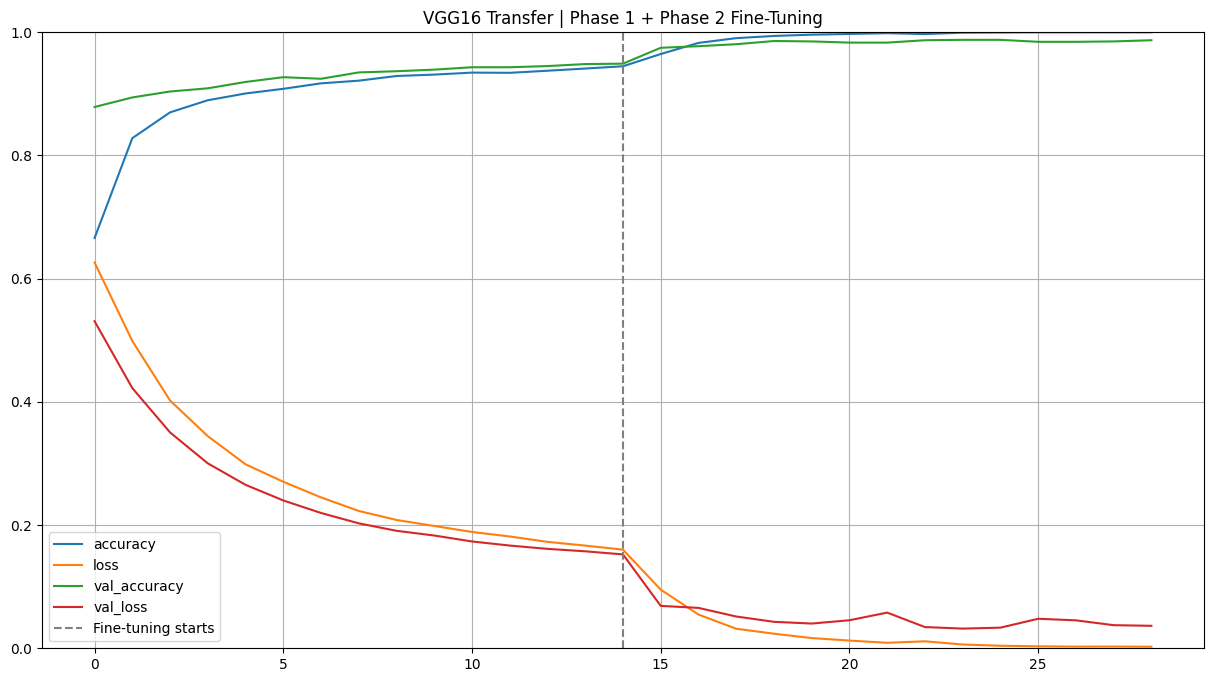

In [ ]:
# ── Graph ─────────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

# Combine both phases into one history for a full picture
combined_history = {}
for key in transfer_history_phase1.history:
    combined_history[key] = (
        transfer_history_phase1.history[key] +
        transfer_history_phase2.history[key]
    )

pd.DataFrame(combined_history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.axvline(x=len(transfer_history_phase1.history['loss']) - 1,
            color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('VGG16 Transfer | Phase 1 + Phase 2 Fine-Tuning')
plt.legend()
plt.show()

Test set: (624, 128, 128, 3) | NORMAL=234, PNEUMONIA=390
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step
              precision    recall  f1-score   support

      NORMAL       0.89      0.88      0.88       234
   PNEUMONIA       0.93      0.93      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.90      0.91       624
weighted avg       0.91      0.91      0.91       624



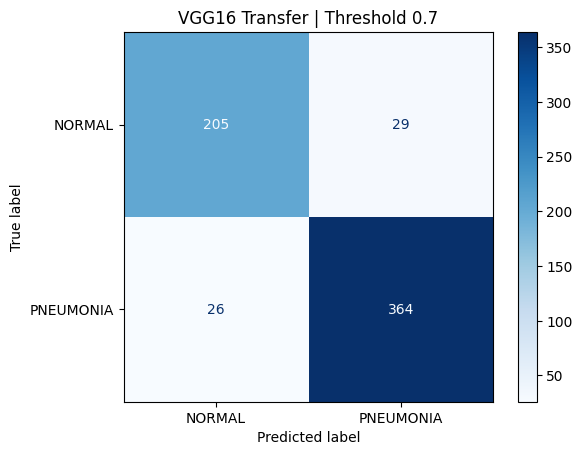

In [ ]:
# ── Load test set ─────────────────────────────────────────────────────────────
# X_test/y_test are not defined above — load them the same way as training images
test_imgs,  test_labels  = load_images_from_folder("chest_xray/test/NORMAL",    0, target_size=(128, 128))
test_imgs2, test_labels2 = load_images_from_folder("chest_xray/test/PNEUMONIA", 1, target_size=(128, 128))

X_test = np.array(test_imgs + test_imgs2)
y_test = np.array(test_labels + test_labels2)

print(f"Test set: {X_test.shape} | NORMAL={sum(y_test==0)}, PNEUMONIA={sum(y_test==1)}")

# ── Evaluation with threshold 0.7 ─────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

transfer_preds     = transfer_model.predict(X_test)
predicted_transfer = (transfer_preds > 0.9992).astype(int).flatten()   # 🔥 threshold 0.7

print(classification_report(y_test, predicted_transfer, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(y_test, predicted_transfer)
ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA']).plot(cmap='Blues')
plt.title('VGG16 Transfer | Threshold 0.7')
plt.show()

In [ ]:
# finidng the best threshold

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
AUC: 0.9636
Best threshold (Youden's J): 0.9993
  → TPR (Pneumonia recall): 0.9308
  → FPR (Normal misclassified): 0.1111


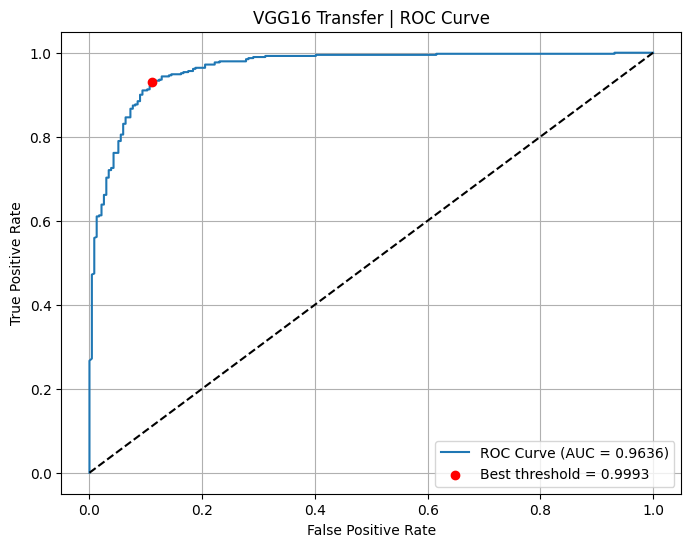


Classification report at threshold 0.9993:
              precision    recall  f1-score   support

      NORMAL       0.88      0.89      0.89       234
   PNEUMONIA       0.93      0.93      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.91      0.91       624
weighted avg       0.91      0.91      0.91       624



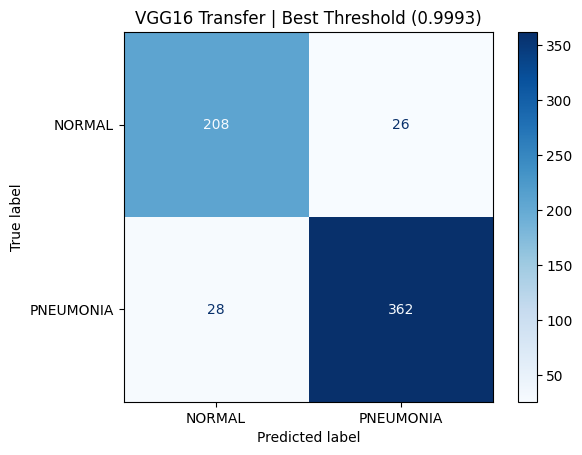

In [ ]:
# ── Find the best threshold using ROC + Youden's J ────────────────────────────
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# Raw probabilities (already computed above)
transfer_preds_raw = transfer_model.predict(X_test).flatten()

# ── ROC curve ────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, transfer_preds_raw)
auc = roc_auc_score(y_test, transfer_preds_raw)

# ── Youden's J: maximizes (TPR - FPR) → best balance point ──────────────────
# This is the standard way to find the optimal threshold mathematically
J = tpr - fpr
best_idx       = np.argmax(J)
best_threshold = thresholds[best_idx]

print(f"AUC: {auc:.4f}")
print(f"Best threshold (Youden's J): {best_threshold:.4f}")
print(f"  → TPR (Pneumonia recall): {tpr[best_idx]:.4f}")
print(f"  → FPR (Normal misclassified): {fpr[best_idx]:.4f}")

# ── Plot ROC with best threshold marked ──────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', zorder=5,
            label=f'Best threshold = {best_threshold:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('VGG16 Transfer | ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# ── Re-evaluate with best threshold ──────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

predicted_best = (transfer_preds_raw > best_threshold).astype(int)

print(f"\nClassification report at threshold {best_threshold:.4f}:")
print(classification_report(y_test, predicted_best, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(y_test, predicted_best)
ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA']).plot(cmap='Blues')
plt.title(f'VGG16 Transfer | Best Threshold ({best_threshold:.4f})')
plt.show()

Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get raw probabilities
transfer_preds_raw = transfer_model.predict(X_test).flatten()

# Default classification (0.5 threshold)
y_pred_default = (transfer_preds_raw > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_default)
print("Confusion Matrix (default 0.5):")
print(cm)

# Optional: full report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=['NORMAL', 'PNEUMONIA']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
Confusion Matrix (default 0.5):
[[108 126]
 [  2 388]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.46      0.63       234
   PNEUMONIA       0.75      0.99      0.86       390

    accuracy                           0.79       624
   macro avg       0.87      0.73      0.74       624
weighted avg       0.84      0.79      0.77       624



## Confusion matrix without a threshhold (this is already good)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
Confusion Matrix (default 0.5):
[[108 126]
 [  2 388]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.46      0.63       234
   PNEUMONIA       0.75      0.99      0.86       390

    accuracy                           0.79       624
   macro avg       0.87      0.73      0.74       624
weighted avg       0.84      0.79      0.77       624



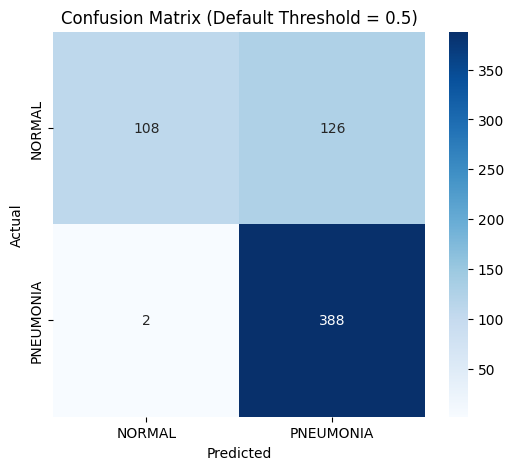

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get raw probabilities
transfer_preds_raw = transfer_model.predict(X_test).flatten()

# Default classification (0.5 threshold)
y_pred_default = (transfer_preds_raw > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_default)

# Print results
print("Confusion Matrix (default 0.5):")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=['NORMAL', 'PNEUMONIA']))

# 🔥 Seaborn heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Default Threshold = 0.5)')
plt.show()

## 7- Saving the Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

save_path = "/content/drive/MyDrive/cristiano"
os.makedirs(save_path, exist_ok=True)

transfer_model.save(f"{save_path}/vgg16_transfer_final_v2.h5")
print("Saved!")

Saved!


In [ ]:
# already done — best_threshold is defined
print(f"Best threshold: {best_threshold:.4f}")

Best threshold: 0.9992


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_path = "/content/drive/MyDrive/messi"
os.makedirs(save_path, exist_ok=True)

transfer_model.save(f"{save_path}/vgg16_transfer_final.h5")
print("Model saved!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved!


In [ ]:
import json

model_config = {"threshold": float(best_threshold)}
with open(f"{save_path}/model_config.json", "w") as f:
    json.dump(model_config, f)

print(f"Threshold {best_threshold:.4f} saved!")

Threshold 0.9992 saved!


In [ ]:
!ls /content/drive/MyDrive/messi
# should show: vgg16_transfer_final.h5   model_config.json

model_config.json  vgg16_transfer_final.h5


# Testing the model performance

In [ ]:
print('hello')

hello


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, transfer_preds_raw)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.963598509752356


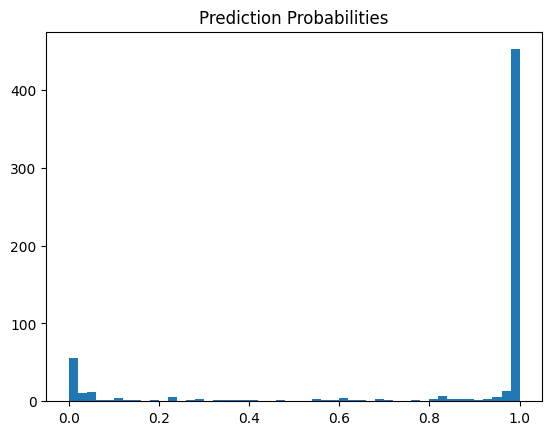

In [ ]:
import matplotlib.pyplot as plt

plt.hist(transfer_preds_raw, bins=50)
plt.title("Prediction Probabilities")
plt.show()

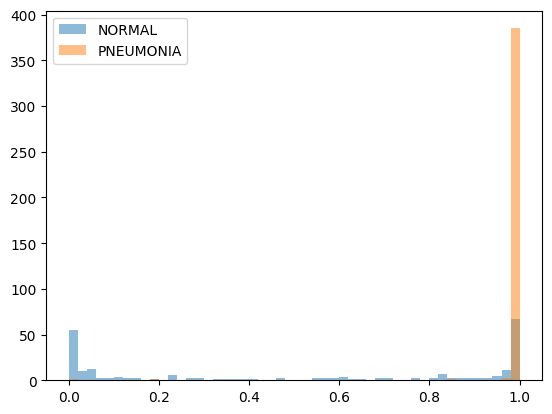

In [ ]:
plt.hist(transfer_preds_raw[y_test==0], bins=50, alpha=0.5, label='NORMAL')
plt.hist(transfer_preds_raw[y_test==1], bins=50, alpha=0.5, label='PNEUMONIA')
plt.legend()
plt.show()